# HOSPITAL VISIT DATA ANALYSIS

### Importing useful libraries

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandoc

### Loading and exploring data

In [4]:
df = pd.read_csv("Hospital_Visits_Dataset.csv")

df.head()

,visit_id,patient_name,gender,age,blood_group,state,city,department,attending_physician,admission_type,diagnosis,insurance_type,admission_date,discharge_date,length_of_stay_days,wait_time_minutes,bill_amount_ngn,outcome,readmitted_within_30_days
0,HV00001,Hannah Powell,Male,43,B+,Oyo,Ibadan,Pediatrics,Dr. Fatima Ali,Referral,Malaria,HMO,2025-06-03,2025-06-07,4,185,143932.07,Discharged,No
1,HV00002,Justin Christian,Female,40,O-,Abuja,Garki,Oncology,Dr. Musa Bello,Referral,Pneumonia,HMO,2025-03-13,2025-03-24,11,208,163864.50,Discharged,Yes
2,HV00003,Carolyn Elliott,Female,20,AB+,Oyo,Ibadan,Obstetrics,Dr. Chinedu Okafor,Referral,Ulcer,HMO,2025-11-23,2025-11-30,7,50,78583.01,Discharged,No
3,HV00004,Deborah Navarro,Female,83,A+,Abuja,Wuse,Obstetrics,Dr. Fatima Ali,Walk-in,Typhoid,NHIS,2025-08-13,2025-09-01,19,70,187634.62,Discharged,No
4,HV00005,Deanna Gaines,Female,72,O-,Rivers,Port Harcourt,Pediatrics,Dr. Musa Bello,Emergency,Diabetes,HMO,2025-10-15,2025-10-31,16,141,233759.10,Discharged,Yes


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   visit_id                   10000 non-null  str    
 1   patient_name               10000 non-null  str    
 2   gender                     10000 non-null  str    
 3   age                        10000 non-null  int64  
 4   blood_group                10000 non-null  str    
 5   state                      10000 non-null  str    
 6   city                       10000 non-null  str    
 7   department                 10000 non-null  str    
 8   attending_physician        10000 non-null  str    
 9   admission_type             10000 non-null  str    
 10  diagnosis                  10000 non-null  str    
 11  insurance_type             10000 non-null  str    
 12  admission_date             10000 non-null  str    
 13  discharge_date             10000 non-null  str    
 14  le

In [7]:
df['admission_date'] = pd.to_datetime(df['admission_date'])
df['discharge_date'] = pd.to_datetime(df['admission_date'])

In [9]:
# Statistic
df.describe()

,age,admission_date,discharge_date,length_of_stay_days,wait_time_minutes,bill_amount_ngn
count,10000.00000,10000,10000,10000.000000,10000.000000,10000.000000
mean,45.13830,2025-07-29 11:30:54.720000,2025-07-29 11:30:54.720000,10.377000,122.059800,121612.307603
min,0.00000,2024-07-28 00:00:00,2024-07-28 00:00:00,1.000000,5.000000,5000.000000
25%,23.00000,2025-01-28 00:00:00,2025-01-28 00:00:00,5.000000,63.000000,72143.045000
50%,45.00000,2025-07-31 00:00:00,2025-07-31 00:00:00,10.000000,122.000000,120332.275000
75%,68.00000,2026-01-28 00:00:00,2026-01-28 00:00:00,15.000000,181.000000,167801.515000
max,90.00000,2026-07-28 00:00:00,2026-07-28 00:00:00,20.000000,240.000000,363865.440000
std,26.19172,NaN,NaN,5.798761,68.177043,67423.370210


### Value Counts

In [14]:
df.columns

Index(['visit_id', 'patient_name', 'gender', 'age', 'blood_group', 'state',
       'city', 'department', 'attending_physician', 'admission_type',
       'diagnosis', 'insurance_type', 'admission_date', 'discharge_date',
       'length_of_stay_days', 'wait_time_minutes', 'bill_amount_ngn',
       'outcome', 'readmitted_within_30_days'],
      dtype='str')

In [16]:
df['admission_type'].value_counts()

admission_type
Emergency    3557
Walk-in      2942
Scheduled    2015
Referral     1486
Name: count, dtype: int64

In [17]:
df['gender'].value_counts()

gender
Male      5040
Female    4960
Name: count, dtype: int64

In [18]:
df['blood_group'].value_counts()

blood_group
AB+    1327
O-     1268
B+     1255
A-     1243
B-     1233
AB-    1233
A+     1231
O+     1210
Name: count, dtype: int64

In [20]:
df['state'].value_counts()

state
Lagos     2534
Abuja     2507
Oyo       2490
Rivers    2469
Name: count, dtype: int64

In [27]:
physician = df['attending_physician'].nunique()

print("Total number of physician:", physician)

Total number of physician: 6


In [28]:
department = df['department'].nunique()

print("Total number of departments:", department)

Total number of departments: 8


In [29]:
df['diagnosis'].value_counts()

diagnosis
Diabetes        1051
Stroke          1049
Fracture        1014
Typhoid         1010
Pneumonia       1006
Malaria         1000
Asthma           996
Hypertension     984
Pregnancy        954
Ulcer            936
Name: count, dtype: int64

### Group By Analysis

In [23]:
# Volume of visits by department
dept = df.groupby('department')['visit_id'].count()

print(dept)

department
Cardiology     1207
Emergency      2458
Neurology       605
Obstetrics     1550
Oncology        590
Orthopedics     954
Pediatrics     1180
Surgery        1456
Name: visit_id, dtype: int64


### Average waiting time by deparment

In [30]:
df.groupby('department')['wait_time_minutes'].mean().sort_values(ascending=False)

department
Surgery        124.328297
Neurology      123.525620
Obstetrics     123.303871
Orthopedics    123.038784
Pediatrics     122.438136
Emergency      121.422295
Oncology       118.998305
Cardiology     118.642088
Name: wait_time_minutes, dtype: float64

### Revenue by state

In [31]:
df.groupby('state')['bill_amount_ngn'].sum().sort_values(ascending=False)

state
Rivers    3.053386e+08
Oyo       3.053020e+08
Lagos     3.040623e+08
Abuja     3.014201e+08
Name: bill_amount_ngn, dtype: float64

### Length of stay by department

In [47]:
df.groupby('department')['length_of_stay_days'].mean()

department
Cardiology     10.483844
Emergency      10.311635
Neurology      10.380165
Obstetrics     10.318065
Oncology       10.635593
Orthopedics    10.353249
Pediatrics     10.395763
Surgery        10.355769
Name: length_of_stay_days, dtype: float64

### Readmission Rate

In [32]:
(
    df.groupby('department')['readmitted_within_30_days']
      .value_counts(normalize=True)
      .mul(100)
)

department   readmitted_within_30_days
Cardiology   No                           87.738194
             Yes                          12.261806
Emergency    No                           88.689992
             Yes                          11.310008
Neurology    No                           86.942149
             Yes                          13.057851
Obstetrics   No                           86.064516
             Yes                          13.935484
Oncology     No                           88.983051
             Yes                          11.016949
Orthopedics  No                           88.888889
             Yes                          11.111111
Pediatrics   No                           88.644068
             Yes                          11.355932
Surgery      No                           87.019231
             Yes                          12.980769
Name: proportion, dtype: float64

### Revenue by department and insurance

In [48]:
pd.pivot_table(
    df,
    values='bill_amount_ngn',
    index='department',
    columns='insurance_type',
    aggfunc='sum'
)

insurance_type,HMO,NHIS,Out-of-Pocket
department,,,
Cardiology,44363243.46,5.086561e+07,4.967022e+07
Emergency,90819502.32,1.091176e+08,1.016702e+08
Neurology,22514833.27,2.787261e+07,2.605058e+07
Obstetrics,55120492.18,6.862794e+07,6.031580e+07
Oncology,19248003.48,2.599622e+07,2.685442e+07
Orthopedics,32767590.09,4.160696e+07,3.974725e+07
Pediatrics,43044239.15,4.960188e+07,5.123791e+07
Surgery,52444528.80,6.613266e+07,6.043279e+07


### Average Waiting time

In [49]:
pd.pivot_table(df, values="wait_time_minutes", index="department", aggfunc="mean")

,wait_time_minutes
department,
Cardiology,118.642088
Emergency,121.422295
Neurology,123.525620
Obstetrics,123.303871
Oncology,118.998305
Orthopedics,123.038784
Pediatrics,122.438136
Surgery,124.328297


### Age Group

In [57]:
df['age_group'] = np.where(
    df['age'] < 18,
    'Child',
    np.where(df['age'] < 60, 'Adult', 'Senior')
)

df.head()

,visit_id,patient_name,gender,age,blood_group,state,city,department,attending_physician,admission_type,diagnosis,insurance_type,admission_date,discharge_date,length_of_stay_days,wait_time_minutes,bill_amount_ngn,outcome,readmitted_within_30_days,age_group
0,HV00001,Hannah Powell,Male,43,B+,Oyo,Ibadan,Pediatrics,Dr. Fatima Ali,Referral,Malaria,HMO,2025-06-03,2025-06-03,4,185,143932.07,Discharged,No,Adult
1,HV00002,Justin Christian,Female,40,O-,Abuja,Garki,Oncology,Dr. Musa Bello,Referral,Pneumonia,HMO,2025-03-13,2025-03-13,11,208,163864.50,Discharged,Yes,Adult
2,HV00003,Carolyn Elliott,Female,20,AB+,Oyo,Ibadan,Obstetrics,Dr. Chinedu Okafor,Referral,Ulcer,HMO,2025-11-23,2025-11-23,7,50,78583.01,Discharged,No,Adult
3,HV00004,Deborah Navarro,Female,83,A+,Abuja,Wuse,Obstetrics,Dr. Fatima Ali,Walk-in,Typhoid,NHIS,2025-08-13,2025-08-13,19,70,187634.62,Discharged,No,Senior
4,HV00005,Deanna Gaines,Female,72,O-,Rivers,Port Harcourt,Pediatrics,Dr. Musa Bello,Emergency,Diabetes,HMO,2025-10-15,2025-10-15,16,141,233759.10,Discharged,Yes,Senior


## Data Visualization

### Monthly Admission

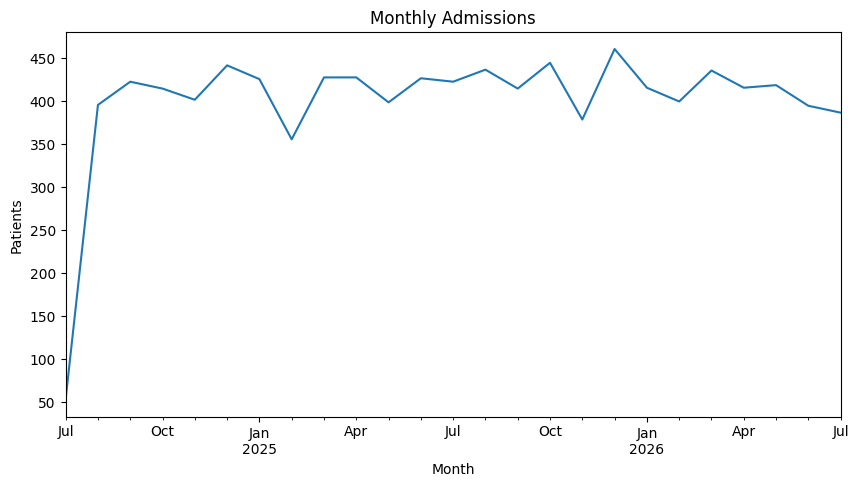

In [33]:
monthly = (
    df.groupby(df['admission_date'].dt.to_period('M'))
      .size()
)

monthly.plot(figsize=(10,5))

plt.title("Monthly Admissions")
plt.xlabel("Month")
plt.ylabel("Patients")
plt.show()

### Revenue by Department

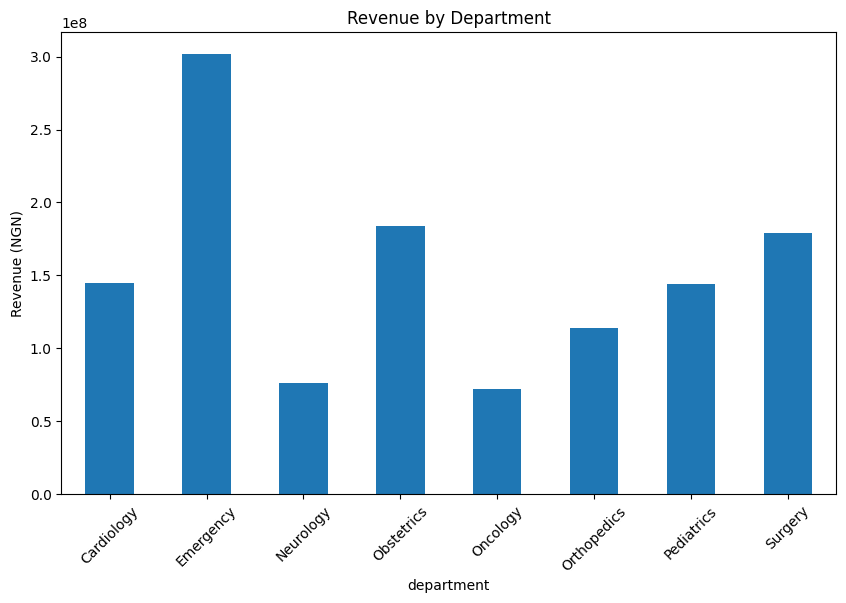

In [34]:
rev = df.groupby('department')['bill_amount_ngn'].sum()

plt.figure(figsize=(10,6))

rev.plot(kind='bar')

plt.title("Revenue by Department")
plt.ylabel("Revenue (NGN)")
plt.xticks(rotation=45)

plt.show()

### Age distribution

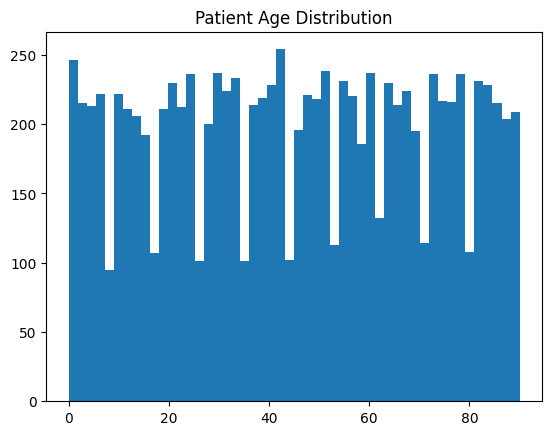

In [36]:
plt.hist(df['age'], bins=50)

plt.title("Patient Age Distribution")

plt.show()

### Insurance Type Distribution

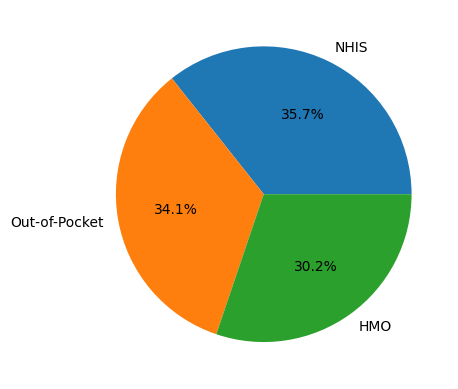

In [40]:
insurance = df['insurance_type'].value_counts()

insurance.plot(kind='pie', autopct='%1.1f%%')

plt.ylabel("")
plt.show()

### Patients by department

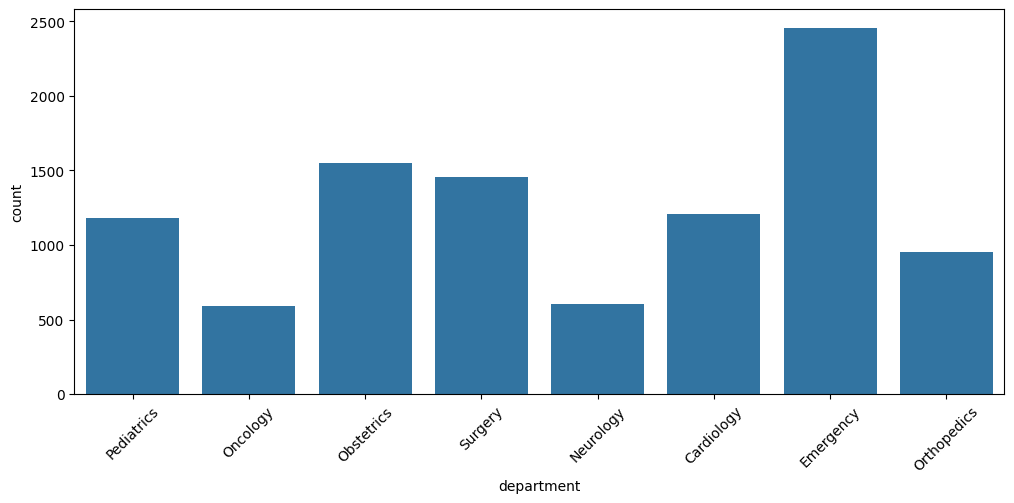

In [41]:
plt.figure(figsize=(12,5))

sns.countplot(data=df, x='department')

plt.xticks(rotation=45)

plt.show()

### Waiting Time

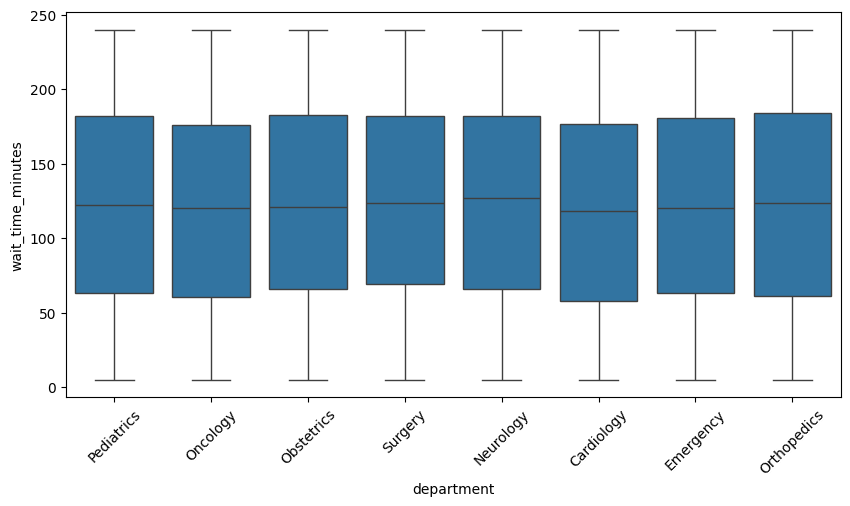

In [44]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x='department',
    y='wait_time_minutes'
)

plt.xticks(rotation=45)

plt.show()

### Age vs Bill Amount

<Axes: xlabel='age', ylabel='bill_amount_ngn'>

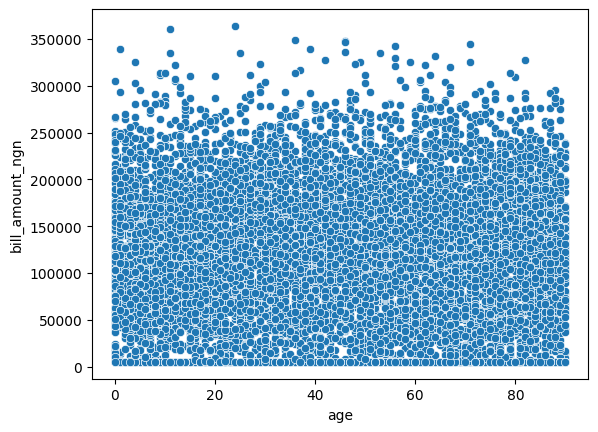

In [45]:
sns.scatterplot(
    data=df,
    x='age',
    y='bill_amount_ngn'
)

### Correlation

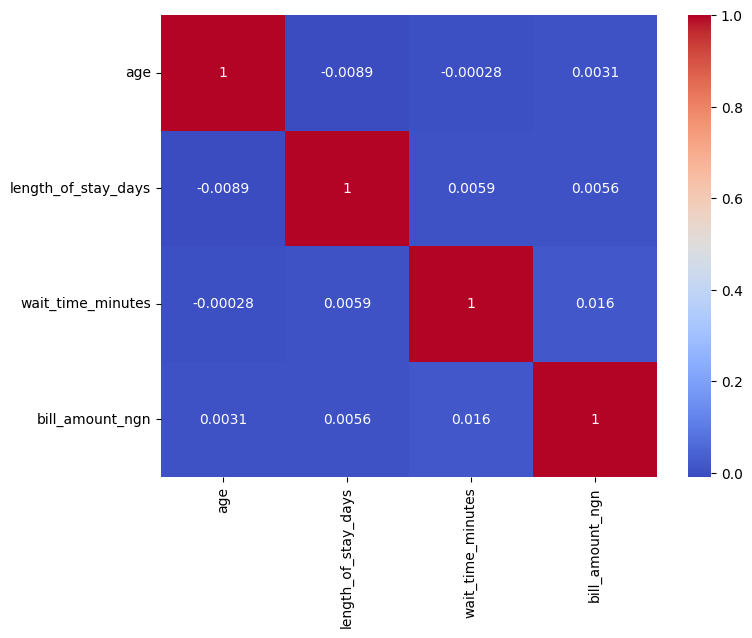

In [46]:
corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.show()